
  Divide-like  (Pe=0.5)
  CFL dt = 0.00404  (u_max=0.500, w_max=1.0000)
  Running 1485 steps  (t_total=6.0 residence times)
    step      0/1485  |  max(X)=0.004  mean(X)=0.004
    step    185/1485  |  max(X)=0.752  mean(X)=0.620
    step    370/1485  |  max(X)=1.499  mean(X)=1.009
    step    555/1485  |  max(X)=2.246  mean(X)=1.198
    step    740/1485  |  max(X)=2.994  mean(X)=1.291
    step    925/1485  |  max(X)=3.741  mean(X)=1.357
    step   1110/1485  |  max(X)=4.489  mean(X)=1.409
    step   1295/1485  |  max(X)=5.236  mean(X)=1.453
    step   1480/1485  |  max(X)=5.984  mean(X)=1.492

  Ice stream   (Pe=4.0)
  CFL dt = 0.00067  (u_max=4.000, w_max=2.5656)
  Running 8939 steps  (t_total=6.0 residence times)
    step      0/8939  |  max(X)=0.001  mean(X)=0.001
    step   1117/8939  |  max(X)=0.750  mean(X)=0.184
    step   2234/8939  |  max(X)=1.500  mean(X)=0.232
    step   3351/8939  |  max(X)=2.250  mean(X)=0.278
    step   4468/8939  |  max(X)=2.999  mean(X)=0.324
    step

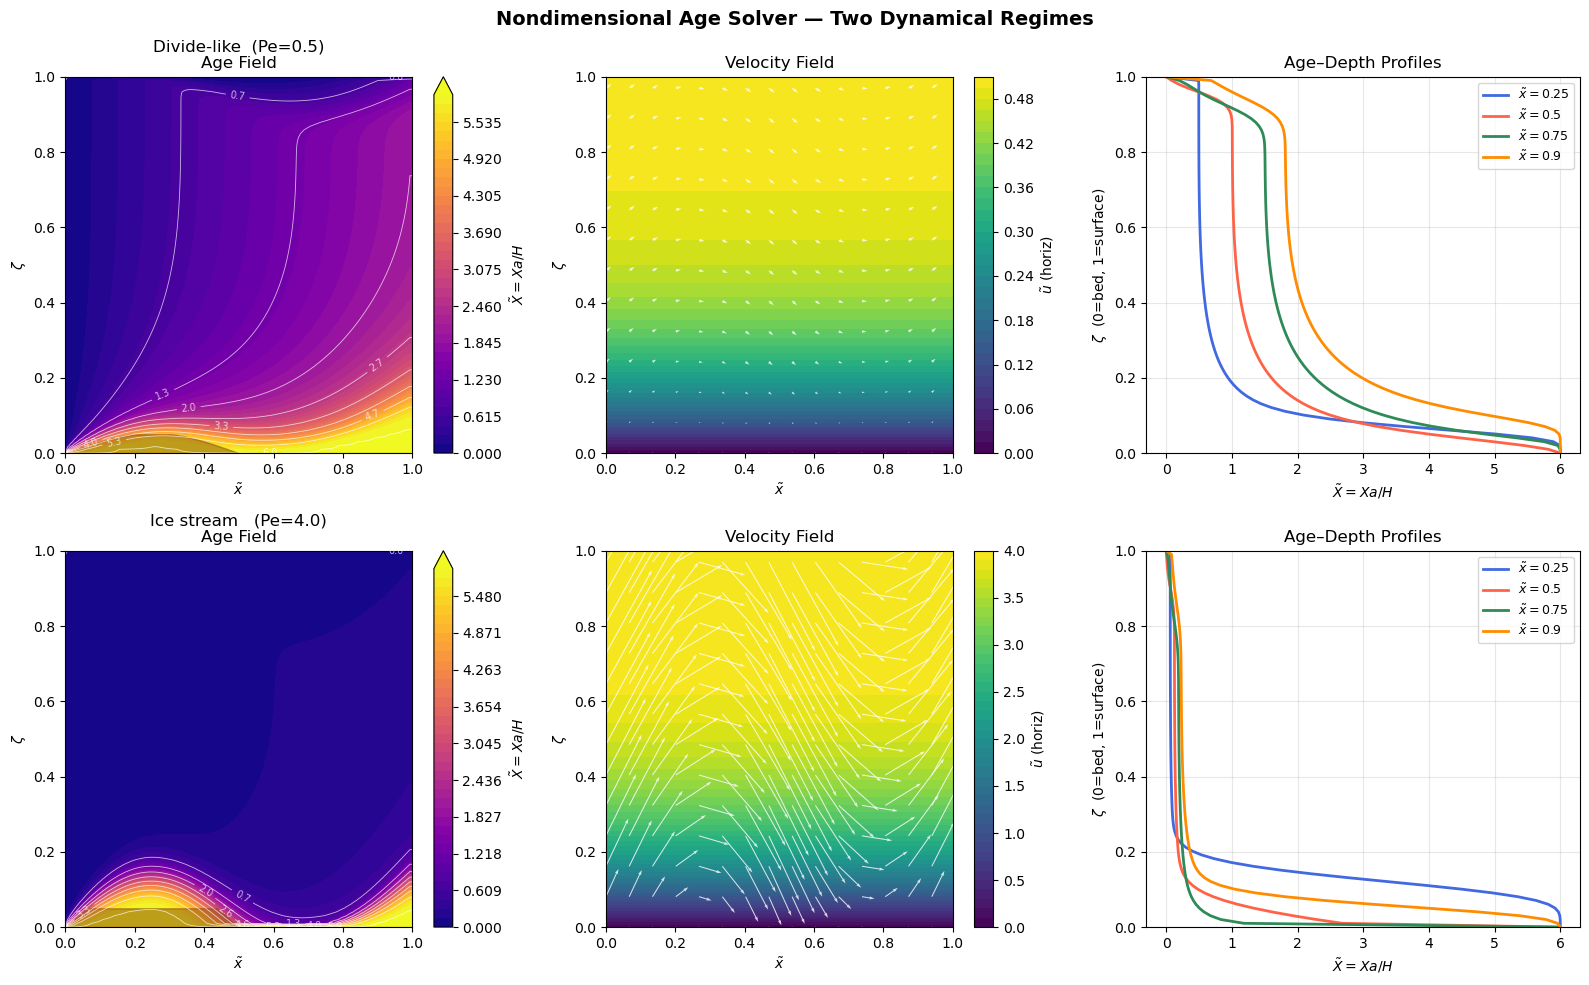


Done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

class SigmaAgeModel:
    """
    Nondimensional ice age solver in sigma (terrain-following) coordinates.

    PDE:  dX/dt + u_tilde * dX/dx + w_sigma * dX/dzeta = 1

    Nondimensionalisation:
        x_tilde = x / L
        zeta    = (z - b(x)) / H(x)   in [0,1]
        t_tilde = t * a / H
        X_tilde = X * a / H
        u_tilde = u / (L*a/H)  =>  u_tilde_max = Pe at surface
        w_tilde = w_sigma / (a/H)

    BCs:
        X = 0  at zeta = 1  (surface: fresh snow)
        X = 0  at x = 0     (inflow divide: ice enters young)
        dX/dx = 0 at x = 1  (outflow: zero-gradient, ice exits freely)
    """

    def __init__(self, nx=150, nz=100, Pe=2.0, bed_amp=0.08, cfl_safety=0.4):
        self.nx = nx
        self.nz = nz
        self.Pe = Pe
        self.bed_amp = bed_amp
        self.cfl_safety = cfl_safety

        # ── Grid ──────────────────────────────────────────────────────────────
        self.x    = np.linspace(0, 1, nx)
        self.zeta = np.linspace(0, 1, nz)
        self.dx   = self.x[1]    - self.x[0]
        self.dz   = self.zeta[1] - self.zeta[0]
        self.XX, self.ZZ = np.meshgrid(self.x, self.zeta)  # (nz, nx)

        # ── Geometry ──────────────────────────────────────────────────────────
        # Sinusoidal bed undulation (normalised by mean H)
        self.b_tilde  = bed_amp * np.sin(2 * np.pi * self.x)
        # Gentle downstream surface slope
        self.s_tilde  = 1.0 - 0.05 * self.x
        self.H_tilde  = self.s_tilde - self.b_tilde          # ~1 everywhere
        self.dHdx     = np.gradient(self.H_tilde, self.x)
        self.dbdx     = np.gradient(self.b_tilde,  self.x)

        # ── Velocity ──────────────────────────────────────────────────────────
        self._build_velocity()

        # ── Auto timestep from CFL ────────────────────────────────────────────
        u_max = np.abs(self.u).max()
        w_max = np.abs(self.w).max() + 1e-12
        self.dt = cfl_safety * min(self.dx / u_max, self.dz / w_max)
        print(f"  CFL dt = {self.dt:.5f}  "
              f"(u_max={u_max:.3f}, w_max={w_max:.4f})")

        # ── Age field ─────────────────────────────────────────────────────────
        self.X = np.zeros((nz, nx))

    # ─────────────────────────────────────────────────────────────────────────
    def _build_velocity(self):
        """
        Lliboutry horizontal profile + incompressibility-derived sigma velocity.
        """
        ZZ = self.ZZ

        # Lliboutry shape (p=3), normalised so omega(1)=1
        p = 3.0
        omega  = ((p+2)/(p+1)) * (1-(1-ZZ)**(p+1)) \
               - (1/(p+1))     * (1-(1-ZZ)**(p+2))
        omega /= omega[-1, 0]

        # Horizontal velocity: u_tilde = Pe * omega(zeta)
        # Broadcast over x (parallel flow assumption)
        self.u = self.Pe * omega                              # (nz, nx)

        # du/dx at constant zeta = 0 (parallel flow)
        dudx_sigma = np.zeros_like(self.u)

        # du/dzeta for metric correction
        dudz = np.gradient(self.u, self.zeta, axis=0)

        # Metric term: (zeta*dH/dx + db/dx) / H * du/dzeta
        dHdx_2d = self.dHdx[np.newaxis, :]                   # (1, nx)
        dbdx_2d = self.dbdx[np.newaxis, :]
        H_2d    = self.H_tilde[np.newaxis, :]
        metric  = (self.ZZ * dHdx_2d + dbdx_2d) / H_2d * dudz

        # Integrate dw/dzeta from bed (w=0 at zeta=0, no basal melt)
        dwdz_rhs = -dudx_sigma + metric
        self.w   = np.zeros_like(self.u)
        for k in range(1, self.nz):
            self.w[k, :] = self.w[k-1, :] + self.dz * dwdz_rhs[k-1, :]

        # w should be negative (downward in sigma) in the interior
        # At surface: w_sigma = -(accumulation) = -1 in nondim units
        # Enforce surface value explicitly
        self.w[-1, :] = -1.0

    # ─────────────────────────────────────────────────────────────────────────
    def _upwind_step(self, X):
        """First-order upwind advection + source term."""
        dX = np.zeros_like(X)

        # ── Horizontal: u > 0 everywhere → backward difference ───────────────
        dXdx          = np.zeros_like(X)
        dXdx[:, 1:]   = (X[:, 1:] - X[:, :-1]) / self.dx
        dXdx[:, 0]    = 0.0   # inflow: handled by BC

        # ── Vertical: split by sign of w ─────────────────────────────────────
        w_neg = np.minimum(self.w, 0.0)   # downward component
        w_pos = np.maximum(self.w, 0.0)   # upward component (near bed)

        fwd          = np.zeros_like(X)   # forward difference (for w<0)
        fwd[:-1, :]  = (X[1:, :] - X[:-1, :]) / self.dz
        fwd[-1,  :]  = 0.0

        bwd          = np.zeros_like(X)   # backward difference (for w>0)
        bwd[1:,  :]  = (X[1:, :] - X[:-1, :]) / self.dz
        bwd[0,   :]  = 0.0

        dXdz = w_neg * fwd + w_pos * bwd

        # ── Combine with source ───────────────────────────────────────────────
        dX = -self.u * dXdx - dXdz + 1.0
        return dX

    # ─────────────────────────────────────────────────────────────────────────
    def _apply_bcs(self, X):
        X[-1, :]  = 0.0          # surface: age = 0
        X[:,  0]  = 0.0          # inflow divide: age = 0
        X[:,  -1] = X[:, -2]     # outflow: zero-gradient (Neumann)
        X          = np.maximum(X, 0.0)
        return X

    # ─────────────────────────────────────────────────────────────────────────
    def run(self, n_residence_times=6, verbose=True):
        """
        Run until n_residence_times * (H/a) have elapsed.
        Steady state is typically reached within ~3 residence times.
        """
        # Total nondim time to integrate
        t_total = n_residence_times
        nt      = int(t_total / self.dt)

        X = self._apply_bcs(self.X.copy())

        print(f"  Running {nt} steps  (t_total={t_total:.1f} residence times)")

        for n in range(nt):
            dX = self._upwind_step(X)
            X  = X + self.dt * dX
            X  = self._apply_bcs(X)

            if verbose and (n % max(1, nt//8) == 0):
                print(f"    step {n:6d}/{nt}  |  "
                      f"max(X)={X.max():.3f}  mean(X)={X.mean():.3f}")

        self.X = X
        return X

    # ─────────────────────────────────────────────────────────────────────────
    def plot(self, ax_row=None, fig=None):
        """Plot age field, velocity, and age-depth profiles."""
        own_fig = ax_row is None
        if own_fig:
            fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        else:
            axes = ax_row

        X = self.X

        # Panel 1: Age field
        ax = axes[0]
        vmax = np.percentile(X, 98)
        cf = ax.contourf(self.XX, self.ZZ, X,
                         levels=np.linspace(0, vmax, 40), cmap='plasma',
                         extend='max')
        cs = ax.contour(self.XX, self.ZZ, X,
                        levels=np.linspace(0, vmax, 10),
                        colors='white', linewidths=0.6, alpha=0.7)
        ax.clabel(cs, fmt='%.1f', fontsize=7, colors='white')
        plt.colorbar(cf, ax=ax, label=r'$\tilde{X} = Xa/H$')
        # Bed topography shading
        bed_norm = self.b_tilde / self.H_tilde
        ax.fill_between(self.x, 0, np.clip(bed_norm, -0.05, 0.05),
                        color='saddlebrown', alpha=0.5)
        ax.set_xlabel(r'$\tilde{x}$'); ax.set_ylabel(r'$\zeta$')
        ax.set_title(f'Pe={self.Pe:.1f} | Age Field')
        ax.set_xlim(0,1); ax.set_ylim(0,1)

        # Panel 2: Velocity magnitude + streamlines
        ax = axes[1]
        speed = np.sqrt(self.u**2 + (self.w * self.dx/self.dz)**2)
        cf2 = ax.contourf(self.XX, self.ZZ, self.u,
                          levels=40, cmap='viridis')
        plt.colorbar(cf2, ax=ax, label=r'$\tilde{u}$ (horiz)')
        skip = (slice(None,None,8), slice(None,None,10))
        ax.quiver(self.XX[skip], self.ZZ[skip],
                  self.u[skip], self.w[skip]*3,
                  color='white', scale=30, width=0.003, alpha=0.8)
        ax.set_xlabel(r'$\tilde{x}$'); ax.set_ylabel(r'$\zeta$')
        ax.set_title('Velocity Field')
        ax.set_xlim(0,1); ax.set_ylim(0,1)

        # Panel 3: Age-depth profiles
        ax = axes[2]
        cols = ['royalblue','tomato','seagreen','darkorange']
        for col, pos in zip(cols, [0.25, 0.50, 0.75, 0.90]):
            ix = int(pos * self.nx)
            ax.plot(X[:, ix], self.zeta, color=col, lw=2,
                    label=fr'$\tilde{{x}}={pos}$')
        ax.set_xlabel(r'$\tilde{X} = Xa/H$')
        ax.set_ylabel(r'$\zeta$  (0=bed, 1=surface)')
        ax.set_title('Age–Depth Profiles')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        ax.set_ylim(0,1)

        if own_fig:
            plt.tight_layout()
            plt.savefig('sigma_age_model.png', dpi=150, bbox_inches='tight')
            plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    configs = [
        dict(Pe=0.5, bed_amp=0.05, label="Divide-like  (Pe=0.5)"),
        dict(Pe=4.0, bed_amp=0.12, label="Ice stream   (Pe=4.0)"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("Nondimensional Age Solver — Two Dynamical Regimes",
                 fontsize=14, fontweight='bold')

    for row, cfg in enumerate(configs):
        print(f"\n{'='*55}")
        print(f"  {cfg['label']}")
        print(f"{'='*55}")
        model = SigmaAgeModel(
            nx=150, nz=100,
            Pe=cfg['Pe'],
            bed_amp=cfg['bed_amp'],
            cfl_safety=0.4          # auto-computes dt per regime
        )
        model.run(n_residence_times=6, verbose=True)
        model.plot(ax_row=axes[row], fig=fig)
        axes[row, 0].set_title(f"{cfg['label']}\nAge Field")

    plt.tight_layout()
    plt.savefig('sigma_age_two_regimes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nDone.")
